# Sentiment Analysis Using Deep Learning Assignment

This notebook builds a tweet sentiment classifier using two neural approaches and compare their performance.

Dataset files expected in the same working directory: train.csv and test.csv.

In [4]:
colab = True   # True if using Google Colab
linked = True  # True if your Colab Drive has the Colab Notebooks/Assignment folder

if (colab):
  from google.colab import drive
  drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [61]:
# ============================================================
# IMPORTS
# ============================================================

import os
import re
import random
import warnings
warnings.filterwarnings("ignore")
from collections import Counter
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import (
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix
)

import emoji
import torch

# TensorFlow / Keras imports
import tensorflow as tf

Tokenizer = tf.keras.preprocessing.text.Tokenizer
pad_sequences = tf.keras.utils.pad_sequences
EarlyStopping = tf.keras.callbacks.EarlyStopping
Sequential = tf.keras.Sequential
Embedding = tf.keras.layers.Embedding
Bidirectional = tf.keras.layers.Bidirectional
LSTM = tf.keras.layers.LSTM
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout

# PyTorch imports for DistilBERT
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW


# Transformers 2.1.1-compatible imports
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

optimiser = tf.keras.optimizers.Adam(learning_rate=2e-5)

In [6]:
# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("TensorFlow version:", tf.__version__)
print("PyTorch version   :", torch.__version__)

TensorFlow version: 2.19.0
PyTorch version   : 2.10.0+cu128


In [7]:
# ============================================================
# CONFIGURATION
# ============================================================

if colab:
    from google.colab import drive
    drive.mount('/content/gdrive')

    basepath = '/content/gdrive/My Drive/'

    if linked:
        basepath = os.path.join(basepath, 'Colab Notebooks/NLP Assignment 2')
else:
    # LOCAL WINDOWS PATH
    basepath = r"C:\Users\kevin\Desktop\Masters\NLP\Assignment 2"

# File names
TRAIN_FILE = "train.csv"
TEST_FILE = "test.csv"
train_path = os.path.join(basepath, TRAIN_FILE)
test_path = os.path.join(basepath, TEST_FILE)

TEXT_COL = "text"
LABEL_COL = "sentiment"
FILE_ENCODING = "ISO-8859-1"

# Preprocessing settings
LOWERCASE_RNN = True
LOWERCASE_BERT = True
REDUCE_REPEATED_CHARS = True
REMOVE_NEUTRAL_STOPWORDS_FOR_RNN = False
LENGTH_PERCENTILE = 95
VOCAB_SIZE = 20000
OOV_TOKEN = "<OOV>"
BERT_MODEL_NAME = "distilbert-base-uncased"
BERT_MAX_LEN_CAP = 128

# BiLSTM training settings
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DENSE_UNITS = 64
RNN_DROPOUT = 0.3
RNN_EPOCHS = 8
RNN_BATCH_SIZE = 32
RNN_LEARNING_RATE = 1e-3

# DistilBERT training settings
BERT_BATCH_SIZE = 16
BERT_EPOCHS = 3
BERT_LEARNING_RATE = 2e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Mounted at /content/gdrive
Device: cuda


## Task 1: Preprocessing for Neural Sentiment Models

This section prepares the dataset for neural sentiment analysis.

Key design choices:
- emojis and emoticons are preserved as descriptive tokens
- negation is preserved by expanding contractions in the RNN pipeline
- punctuation such as `!` and `?` is kept because it can carry sentiment intensity
- URLs and usernames are normalised
- two text versions are created:
  - `text_rnn` for a word-level BiLSTM
  - `text_bert` for DistilBERT

In [8]:
# ============================================================
# TASK 1A: LOAD DATA
# ============================================================

train_df = pd.read_csv(train_path, encoding="ISO-8859-1")
test_df = pd.read_csv(test_path, encoding="ISO-8859-1")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

train_df.head()

Train shape: (27481, 10)
Test shape : (4815, 9)

Train columns: ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']
Test columns : ['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [9]:
# ============================================================
# TASK 1B: BASIC CLEANING
# ============================================================

train_df = train_df[[TEXT_COL, LABEL_COL]].copy()
test_df = test_df[[TEXT_COL, LABEL_COL]].copy()

train_df = train_df.dropna(subset=[TEXT_COL, LABEL_COL]).drop_duplicates()
test_df = test_df.dropna(subset=[TEXT_COL, LABEL_COL]).drop_duplicates()

train_df[TEXT_COL] = train_df[TEXT_COL].astype(str)
test_df[TEXT_COL] = test_df[TEXT_COL].astype(str)

print("Cleaned train shape:", train_df.shape)
print("Cleaned test shape :", test_df.shape)


Cleaned train shape: (27480, 2)
Cleaned test shape : (3534, 2)


In [10]:
# ============================================================
# TASK 1C: PREPROCESSING RESOURCES
# ============================================================

EMOTICON_MAP = {
    r":-\)": " smile ",
    r":\)": " smile ",
    r":-D": " laugh ",
    r":D": " laugh ",
    r";-\)": " wink ",
    r";\)": " wink ",
    r":-\(": " sad ",
    r":\(": " sad ",
    r":/": " skeptical ",
    r":-\|": " neutral_face ",
    r"<3": " love "
}

CONTRACTION_MAP = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "won't": "will not",
    "wouldn't": "would not",
    "can't": "can not",
    "couldn't": "could not",
    "shouldn't": "should not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "i'm": "i am",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "we're": "we are",
    "you're": "you are",
    "i've": "i have",
    "we've": "we have",
    "they've": "they have",
    "you've": "you have",
    "i'd": "i would",
    "you'd": "you would",
    "they'd": "they would",
    "we'd": "we would",
    "i'll": "i will",
    "you'll": "you will",
    "they'll": "they will",
    "we'll": "we will",
    "n't": " not"
}

PROTECTED_TOKENS = {
    "no", "not", "nor", "never", "none", "nothing", "neither",
    "but", "however", "though", "although", "yet",
    "very", "too", "so", "only", "just"
}

RNN_REMOVABLE_STOPWORDS = set(ENGLISH_STOP_WORDS) - PROTECTED_TOKENS


In [11]:
# ============================================================
# TASK 1D: PREPROCESSING HELPER FUNCTIONS
# ============================================================

def replace_emoticons(text: str) -> str:
    for pattern, replacement in EMOTICON_MAP.items():
        text = re.sub(pattern, replacement, text)
    return text


def convert_emojis_to_words(text: str) -> str:
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = re.sub(r":([a-zA-Z0-9_]+):", r" EMOJI_ ", text)
    return text


def expand_contractions(text: str) -> str:
    for contraction, expanded in CONTRACTION_MAP.items():
        text = re.sub(rf"{re.escape(contraction)}", expanded, text)
    return text


def normalise_special_tokens(text: str) -> str:
    text = re.sub(r"http\S+|www\S+", " <URL> ", text)
    text = re.sub(r"@\w+", " <USER> ", text)
    text = re.sub(r"#(\w+)", r" hashtag_ ", text)
    return text


def reduce_character_repetitions(text: str) -> str:
    return re.sub(r"(.){2,}", r"", text)


def separate_sentiment_punctuation(text: str) -> str:
    return re.sub(r"([!?.,])", r"  ", text)


def remove_unwanted_characters_rnn(text: str) -> str:
    return re.sub(r"[^a-z0-9_!?.,<>' ]+", " ", text)


def clean_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def remove_neutral_stopwords(text: str) -> str:
    tokens = text.split()
    filtered = [tok for tok in tokens if tok not in RNN_REMOVABLE_STOPWORDS]
    return " ".join(filtered)

In [12]:
# ============================================================
# TASK 1E: TWO PREPROCESSING PIPELINES
# ============================================================

def preprocess_for_rnn(text: str) -> str:
    text = str(text)

    if LOWERCASE_RNN:
        text = text.lower()

    text = replace_emoticons(text)
    text = convert_emojis_to_words(text)
    text = normalise_special_tokens(text)
    text = expand_contractions(text)

    if REDUCE_REPEATED_CHARS:
        text = reduce_character_repetitions(text)

    text = separate_sentiment_punctuation(text)
    text = remove_unwanted_characters_rnn(text)
    text = clean_whitespace(text)

    if REMOVE_NEUTRAL_STOPWORDS_FOR_RNN:
        text = remove_neutral_stopwords(text)
        text = clean_whitespace(text)

    return text


def preprocess_for_bert(text: str) -> str:
    text = str(text)

    if LOWERCASE_BERT:
        text = text.lower()

    text = replace_emoticons(text)
    text = convert_emojis_to_words(text)
    text = normalise_special_tokens(text)

    if REDUCE_REPEATED_CHARS:
        text = reduce_character_repetitions(text)

    text = clean_whitespace(text)
    return text

In [13]:
# ============================================================
# TASK 1F: APPLY PREPROCESSING
# ============================================================

train_df["text_rnn"] = train_df[TEXT_COL].apply(preprocess_for_rnn)
train_df["text_bert"] = train_df[TEXT_COL].apply(preprocess_for_bert)

test_df["text_rnn"] = test_df[TEXT_COL].apply(preprocess_for_rnn)
test_df["text_bert"] = test_df[TEXT_COL].apply(preprocess_for_bert)

train_df[[TEXT_COL, "text_rnn", "text_bert", LABEL_COL]].head()


,text,text_rnn,text_bert,sentiment
0,"I`d have responded, if I were going",i d have responded if i were going,"i`d have responded, if i were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad i will miss you here in san diego,sooo sad i will miss you here in san diego!!!,negative
2,my boss is bullying me...,my boss is bullying me,my boss is bullying me...,negative
3,what interview! leave me alone,what interview leave me alone,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",sons of why couldn t they put them on the rele...,"sons of ****, why couldn`t they put them on th...",negative


In [14]:
# ============================================================
# TASK 1G: INSPECT BEFORE / AFTER EXAMPLES
# ============================================================

sample_indices = np.random.choice(train_df.index, size=min(5, len(train_df)), replace=False)

for idx in sample_indices:
    print("RAW TEXT :", train_df.loc[idx, TEXT_COL])
    print("RNN TEXT :", train_df.loc[idx, "text_rnn"])
    print("BERT TEXT:", train_df.loc[idx, "text_bert"])
    print("LABEL    :", train_df.loc[idx, LABEL_COL])
    print("=" * 100)

RAW TEXT :  Enjoy! Family trumps everything
RNN TEXT : enjoy family trumps everything
BERT TEXT: enjoy! family trumps everything
LABEL    : positive
RAW TEXT :  --of them kinda turns me off of it all.  And then I buy more of them and dig a deeper hole, etc. ;;
RNN TEXT : of them kinda turns me off of it all and then i buy more of them and dig a deeper hole etc
BERT TEXT: --of them kinda turns me off of it all. and then i buy more of them and dig a deeper hole, etc. ;;
LABEL    : negative
RAW TEXT : Clive it`s my birthday pat me  http://apps.facebook.com/dogbook/profile/view/6386106
RNN TEXT : clive it s my birthday pat me http skeptical apps facebook com dogbook profile view 6386106
BERT TEXT: clive it`s my birthday pat me http skeptical /apps.facebook.com/dogbook/profile/view/6386106
LABEL    : neutral
RAW TEXT :  congrats hey
RNN TEXT : congrats hey
BERT TEXT: congrats hey
LABEL    : positive
RAW TEXT : is texting
RNN TEXT : is texting
BERT TEXT: is texting
LABEL    : neutral


In [15]:
# ============================================================
# TASK 1H: LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

train_df["label_id"] = label_encoder.fit_transform(train_df[LABEL_COL])
test_df["label_id"] = label_encoder.transform(test_df[LABEL_COL])

print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

num_classes = len(label_encoder.classes_)
print("num_classes =", num_classes)

Label mapping:
negative -> 0
neutral -> 1
positive -> 2
num_classes = 3


In [16]:
# ============================================================
# TASK 1I: TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_split_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=train_df["label_id"]
)

print("Train split shape:", train_split_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train split shape: (23358, 5)
Validation shape: (4122, 5)
Test shape: (3534, 5)


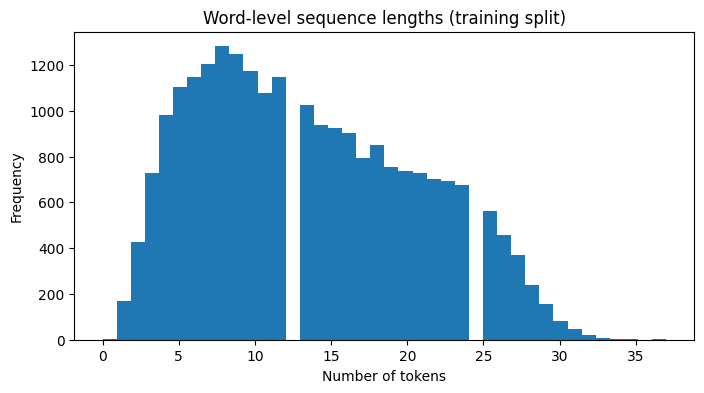

Chosen MAX_LEN_RNN: 26


In [17]:
# ============================================================
# TASK 1J: RNN LENGTH ANALYSIS
# ============================================================

train_split_df["rnn_len"] = train_split_df["text_rnn"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
plt.hist(train_split_df["rnn_len"], bins=40)
plt.title("Word-level sequence lengths (training split)")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

MAX_LEN_RNN = int(np.percentile(train_split_df["rnn_len"], LENGTH_PERCENTILE))
print("Chosen MAX_LEN_RNN:", MAX_LEN_RNN)

# TASK 2 Two Neural Input Representations

This section prepares the two representations required by the brief.

1. **Trainable word embeddings** for the BiLSTM model
2. **Pretrained contextual embeddings** through DistilBERT tokenisation


In [18]:
# ============================================================
# TASK 2A: REPRESENTATION 1 - WORD-LEVEL TOKENISATION
# ============================================================

X_train_rnn = train_split_df["text_rnn"].values
X_val_rnn = val_df["text_rnn"].values
X_test_rnn = test_df["text_rnn"].values

y_train = train_split_df["label_id"].values
y_val = val_df["label_id"].values
y_test = test_df["label_id"].values

num_classes = len(label_encoder.classes_)
print("num_classes:", num_classes)

rnn_tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN,
    filters=""
)

# Fit on training data only to avoid leakage.
rnn_tokenizer.fit_on_texts(X_train_rnn)

X_train_seq = rnn_tokenizer.texts_to_sequences(X_train_rnn)
X_val_seq = rnn_tokenizer.texts_to_sequences(X_val_rnn)
X_test_seq = rnn_tokenizer.texts_to_sequences(X_test_rnn)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN_RNN, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN_RNN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN_RNN, padding="post", truncating="post")

print("Word-level padded train shape:", X_train_pad.shape)
print("Word-level padded validation shape:", X_val_pad.shape)
print("Word-level padded test shape:", X_test_pad.shape)

num_classes: 3
Word-level padded train shape: (23358, 26)
Word-level padded validation shape: (4122, 26)
Word-level padded test shape: (3534, 26)


In [19]:
# ============================================================
# TASK 2B: INSPECT WORD-LEVEL REPRESENTATION
# ============================================================

sample_text = X_train_rnn[0]
sample_seq = X_train_seq[0]

print("Sample RNN text:")
print(sample_text)
print("Sample integer sequence:")
print(sample_seq[:30])
print("First 20 tokenizer entries:")
for word, idx in list(rnn_tokenizer.word_index.items())[:20]:
    print(word, "->", idx)


Sample RNN text:
last time in the drama room
Sample integer sequence:
[101, 57, 11, 4, 1689, 450]
First 20 tokenizer entries:
<OOV> -> 1
i -> 2
to -> 3
the -> 4
a -> 5
my -> 6
it -> 7
you -> 8
and -> 9
is -> 10
in -> 11
for -> 12
s -> 13
t -> 14
of -> 15
that -> 16
me -> 17
on -> 18
so -> 19
have -> 20


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

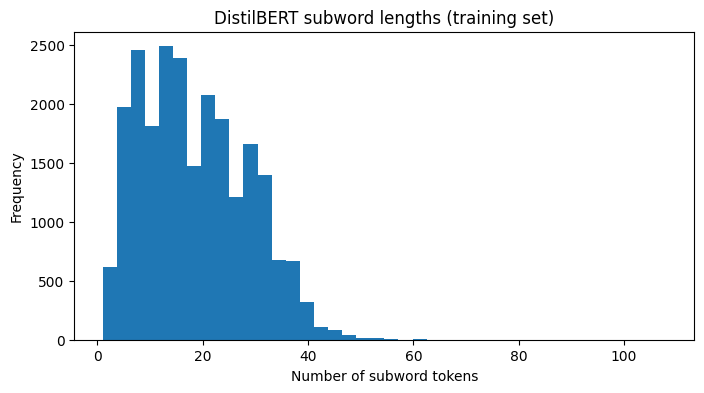

Chosen MAX_LEN_BERT: 36


In [20]:
# ============================================================
# TASK 2C: REPRESENTATION 2 - DISTILBERT TOKENISATION
# Transformers 2.1.1-compatible version
# ============================================================

X_train_bert = train_split_df["text_bert"].tolist()
X_val_bert = val_df["text_bert"].tolist()
X_test_bert = test_df["text_bert"].tolist()

bert_tokenizer = DistilBertTokenizer.from_pretrained(BERT_MODEL_NAME)

# Estimate sequence lengths using the pretrained tokenizer.
bert_lengths = [len(bert_tokenizer.tokenize(text)) for text in X_train_bert]
plt.figure(figsize=(8, 4))
plt.hist(bert_lengths, bins=40)
plt.title("DistilBERT subword lengths (training set)")
plt.xlabel("Number of subword tokens")
plt.ylabel("Frequency")
plt.show()

MAX_LEN_BERT = min(max(int(np.percentile(bert_lengths, LENGTH_PERCENTILE)), 32), BERT_MAX_LEN_CAP)
print("Chosen MAX_LEN_BERT:", MAX_LEN_BERT)

In [21]:
# ============================================================
# TASK 2D: LEGACY-SAFE DISTILBERT ENCODING FUNCTION
# This version works with transformers 2.1.1.
# ============================================================

def encode_with_bert_tokenizer(text_list, tokenizer, max_len):
    input_ids = []
    attention_masks = []

    # DistilBERT uses BERT-style special tokens and padding IDs.
    # We get the PAD token ID safely from the tokenizer.
    pad_token_id = tokenizer.convert_tokens_to_ids(["[PAD]"])[0]

    for text in text_list:
        # Encode text and automatically add special tokens like [CLS] and [SEP]
        ids = tokenizer.encode(
            str(text),
            add_special_tokens=True
        )

        # Truncate if the sequence is too long
        ids = ids[:max_len]

        # Attention mask: 1 for real tokens, 0 for padding
        mask = [1] * len(ids)

        # Pad up to max_len
        padding_length = max_len - len(ids)
        if padding_length > 0:
            ids = ids + [pad_token_id] * padding_length
            mask = mask + [0] * padding_length

        input_ids.append(ids)
        attention_masks.append(mask)

    return {
        "input_ids": np.array(input_ids),
        "attention_mask": np.array(attention_masks)
    }

train_bert_enc = encode_with_bert_tokenizer(X_train_bert, bert_tokenizer, MAX_LEN_BERT)
val_bert_enc = encode_with_bert_tokenizer(X_val_bert, bert_tokenizer, MAX_LEN_BERT)
test_bert_enc = encode_with_bert_tokenizer(X_test_bert, bert_tokenizer, MAX_LEN_BERT)

print("BERT input_ids shape:", train_bert_enc["input_ids"].shape)
print("BERT attention_mask shape:", train_bert_enc["attention_mask"].shape)

BERT input_ids shape: (23358, 36)
BERT attention_mask shape: (23358, 36)


In [22]:
# ============================================================
# TASK 2E: INSPECT DISTILBERT TOKENS
# ============================================================

sample_text = X_train_bert[0]
sample_ids = train_bert_enc["input_ids"][0]
sample_tokens = bert_tokenizer.convert_ids_to_tokens(sample_ids[:30].tolist())

print("Sample BERT text:")
print(sample_text)
print("First 30 BERT tokens:")
print(sample_tokens)


Sample BERT text:
last time in the drama room
First 30 BERT tokens:
['[CLS]', 'last', 'time', 'in', 'the', 'drama', 'room', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


# TASK 3 Two Neural Architectures, Training, and Evaluation

This section trains and evaluates two different neural architectures:

1. **BiLSTM with trainable embeddings**
2. **DistilBERT for sequence classification**

Both models are evaluated with:
- Accuracy
- F1 score

In [23]:
# ============================================================
# TASK 3A: BILSTM MODEL
# ============================================================

def build_bilstm_model(vocab_size, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=max_len),
        Bidirectional(LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2)),
        Dropout(RNN_DROPOUT),
        Dense(DENSE_UNITS, activation="relu"),
        Dropout(RNN_DROPOUT),
        Dense(num_classes, activation="softmax")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=RNN_LEARNING_RATE)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

bilstm_model = build_bilstm_model(VOCAB_SIZE, MAX_LEN_RNN, num_classes)
bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
# ============================================================
# TASK 3B: TRAIN BILSTM MODEL
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=RNN_EPOCHS,
    batch_size=RNN_BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/8
730/730 ━━━━━━━━━━━━━━━━━━━━ 179s 224ms/step - accuracy: 0.6189 - loss: 0.8288 - val_accuracy: 0.7072 - val_loss: 0.6924
Epoch 2/8
730/730 ━━━━━━━━━━━━━━━━━━━━ 181s 206ms/step - accuracy: 0.7725 - loss: 0.5754 - val_accuracy: 0.7018 - val_loss: 0.6982
Epoch 3/8
730/730 ━━━━━━━━━━━━━━━━━━━━ 195s 197ms/step - accuracy: 0.8328 - loss: 0.4405 - val_accuracy: 0.7050 - val_loss: 0.7653


In [25]:
# ============================================================
# TASK 3C: EVALUATE BILSTM MODEL
# ============================================================

bilstm_probs = bilstm_model.predict(X_test_pad)
bilstm_preds = np.argmax(bilstm_probs, axis=1)

bilstm_accuracy = accuracy_score(y_test, bilstm_preds)
bilstm_f1 = f1_score(y_test, bilstm_preds, average="weighted")

print("BiLSTM Accuracy:", bilstm_accuracy)
print("BiLSTM Weighted F1:", bilstm_f1)
print("Classification Report: ")
print(classification_report(y_test, bilstm_preds, target_names=label_encoder.classes_))

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step
BiLSTM Accuracy: 0.7102433503112621
BiLSTM Weighted F1: 0.7104995226953204
Classification Report: 
              precision    recall  f1-score   support

    negative       0.76      0.62      0.68      1001
     neutral       0.64      0.74      0.69      1430
    positive       0.78      0.75      0.76      1103

    accuracy                           0.71      3534
   macro avg       0.73      0.70      0.71      3534
weighted avg       0.72      0.71      0.71      3534



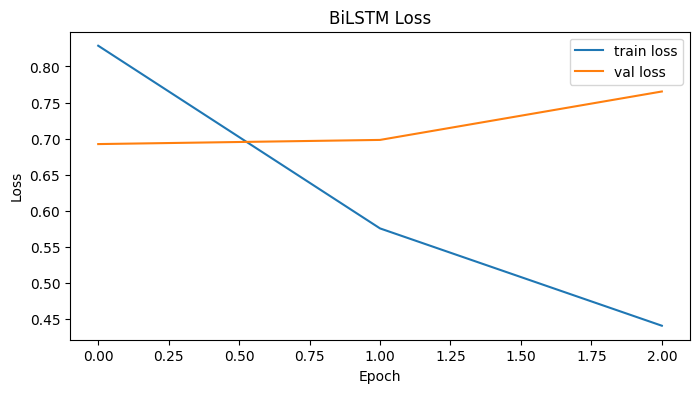

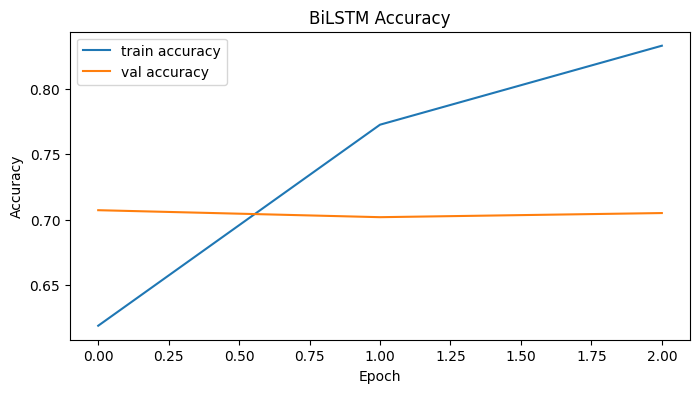

In [26]:
# ============================================================
# TASK 3D: BILSTM LEARNING CURVES
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(history_bilstm.history["loss"], label="train loss")
plt.plot(history_bilstm.history["val_loss"], label="val loss")
plt.title("BiLSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_bilstm.history["accuracy"], label="train accuracy")
plt.plot(history_bilstm.history["val_accuracy"], label="val accuracy")
plt.title("BiLSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [27]:
# ============================================================
# TASK 3E: DISTILBERT DATASET CLASS
# ============================================================

class BertSentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx], dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return item

In [28]:
# ============================================================
# TASK 3F: BUILD DISTILBERT DATA LOADERS
# ============================================================

train_dataset = BertSentimentDataset(train_bert_enc, y_train)
val_dataset = BertSentimentDataset(val_bert_enc, y_val)
test_dataset = BertSentimentDataset(test_bert_enc, y_test)

train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BERT_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BERT_BATCH_SIZE, shuffle=False)

In [29]:
# ============================================================
# TASK 3G: INITIALISE DISTILBERT MODEL
# ============================================================

bert_model = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=num_classes
)

bert_model.to(DEVICE)

bert_optimizer = AdamW(
    bert_model.parameters(),
    lr=BERT_LEARNING_RATE
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
# ============================================================
# TASK 3H: DISTILBERT TRAINING AND EVALUATION HELPERS
# ============================================================

def train_one_epoch_bert(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in data_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs[0]
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)


def evaluate_bert(model, data_loader, device):
    model.eval()
    total_loss = 0
    preds = []
    true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss, logits = outputs[:2]
            total_loss += loss.item()

            batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(batch_preds)
            true_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(true_labels, preds)
    f1 = f1_score(true_labels, preds, average="weighted")
    return total_loss / len(data_loader), acc, f1, np.array(preds), np.array(true_labels)

In [31]:
# ============================================================
# TASK 3I: TRAIN DISTILBERT MODEL
# ============================================================

bert_train_losses = []
bert_val_losses = []
bert_val_accs = []
bert_val_f1s = []

best_val_f1 = -1
best_state_dict = None

for epoch in range(BERT_EPOCHS):
    train_loss = train_one_epoch_bert(bert_model, train_loader, bert_optimizer, DEVICE)
    val_loss, val_acc, val_f1, _, _ = evaluate_bert(bert_model, val_loader, DEVICE)

    bert_train_losses.append(train_loss)
    bert_val_losses.append(val_loss)
    bert_val_accs.append(val_acc)
    bert_val_f1s.append(val_f1)

    print(f"Epoch {epoch+1}/{BERT_EPOCHS}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss  : {val_loss:.4f}")
    print(f"Val acc   : {val_acc:.4f}")
    print(f"Val F1    : {val_f1:.4f}")
    print("-" * 50)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state_dict = {k: v.cpu().clone() for k, v in bert_model.state_dict().items()}

# Restore best checkpoint based on validation F1.
if best_state_dict is not None:
    bert_model.load_state_dict(best_state_dict)
    bert_model.to(DEVICE)

Epoch 1/3
Train loss: 0.5935
Val loss  : 0.5479
Val acc   : 0.7707
Val F1    : 0.7670
--------------------------------------------------
Epoch 2/3
Train loss: 0.4291
Val loss  : 0.5381
Val acc   : 0.7761
Val F1    : 0.7769
--------------------------------------------------
Epoch 3/3
Train loss: 0.3007
Val loss  : 0.6539
Val acc   : 0.7688
Val F1    : 0.7678
--------------------------------------------------


In [32]:
# ============================================================
# TASK 3J: EVALUATE DISTILBERT MODEL
# ============================================================

bert_test_loss, bert_accuracy, bert_f1, bert_preds, bert_true = evaluate_bert(bert_model, test_loader, DEVICE)

print("DistilBERT Accuracy:", bert_accuracy)
print("DistilBERT Weighted F1:", bert_f1)
print("Classification Report: ")
print(classification_report(bert_true, bert_preds, target_names=label_encoder.classes_))

DistilBERT Accuracy: 0.7874929258630448
DistilBERT Weighted F1: 0.7883534532616528
Classification Report: 
              precision    recall  f1-score   support

    negative       0.78      0.82      0.80      1001
     neutral       0.74      0.78      0.76      1430
    positive       0.87      0.78      0.82      1103

    accuracy                           0.79      3534
   macro avg       0.80      0.79      0.79      3534
weighted avg       0.79      0.79      0.79      3534



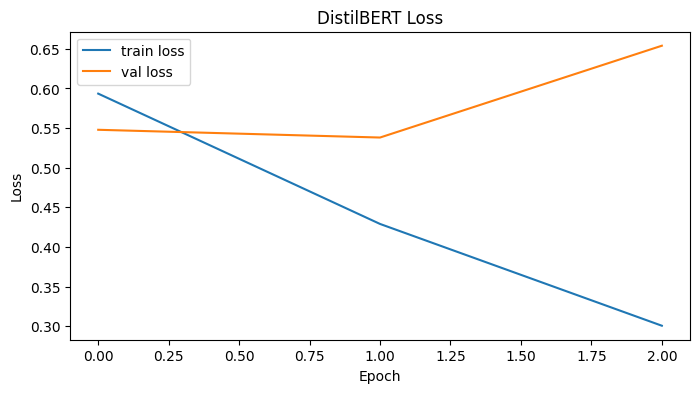

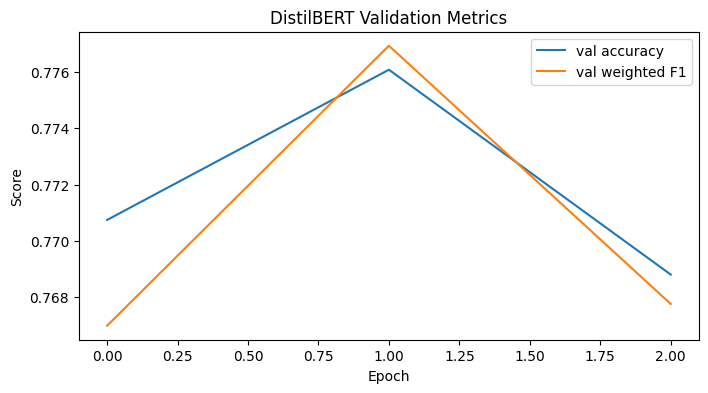

In [33]:
# ============================================================
# TASK 3K: DISTILBERT LEARNING CURVES
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(bert_train_losses, label="train loss")
plt.plot(bert_val_losses, label="val loss")
plt.title("DistilBERT Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(bert_val_accs, label="val accuracy")
plt.plot(bert_val_f1s, label="val weighted F1")
plt.title("DistilBERT Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()

In [34]:
# ============================================================
# TASK 3L: RESULTS TABLE.
# Used the TF-IDF + LinearSVC from Assignment 1
#============================================================

assignment1_accuracy = 0.700623
assignment1_f1 = 0.703172
assignment1_model_name = "TF-IDF + LinearSVC"

results_df = pd.DataFrame([
    {
        "Model": assignment1_model_name,
        "Representation": "TF-IDF / Bag-of-Words",
        "Architecture": "Assignment 1 baseline",
        "Accuracy": assignment1_accuracy,
        "F1": assignment1_f1
    },
    {
        "Model": "BiLSTM",
        "Representation": "Trainable embeddings",
        "Architecture": "Bidirectional LSTM",
        "Accuracy": bilstm_accuracy,
        "F1": bilstm_f1
    },
    {
        "Model": "DistilBERT",
        "Representation": "Pretrained contextual embeddings",
        "Architecture": "Transformer",
        "Accuracy": bert_accuracy,
        "F1": bert_f1
    }
])

results_df

,Model,Representation,Architecture,Accuracy,F1
0,TF-IDF + LinearSVC,TF-IDF / Bag-of-Words,Assignment 1 baseline,0.700623,0.703172
1,BiLSTM,Trainable embeddings,Bidirectional LSTM,0.710243,0.710500
2,DistilBERT,Pretrained contextual embeddings,Transformer,0.787493,0.788353


In [35]:
# ============================================================
# TASK 3M: MISCLASSIFIED EXAMPLES FOR ERROR ANALYSIS
# ============================================================

def show_misclassified_examples(texts, true_labels, pred_labels, encoder, n=10):
    mistakes = []
    for text, true_id, pred_id in zip(texts, true_labels, pred_labels):
        if true_id != pred_id:
            mistakes.append((
                text,
                encoder.inverse_transform([true_id])[0],
                encoder.inverse_transform([pred_id])[0]
            ))

    print(f"Total misclassified examples found: {len(mistakes)}")
    print("=" * 100)

    for text, true_label, pred_label in mistakes[:n]:
        print("TEXT      :", text)
        print("TRUE LABEL:", true_label)
        print("PRED LABEL:", pred_label)
        print("-" * 100)

print("BiLSTM misclassified examples")
show_misclassified_examples(test_df[TEXT_COL].tolist(), y_test, bilstm_preds, label_encoder, n=10)

print("DistilBERT misclassified examples")
show_misclassified_examples(test_df[TEXT_COL].tolist(), bert_true, bert_preds, label_encoder, n=10)

BiLSTM misclassified examples
Total misclassified examples found: 1024
TEXT      :  http://twitpic.com/4w75p - I like it!!
TRUE LABEL: positive
PRED LABEL: neutral
----------------------------------------------------------------------------------------------------
TEXT      :  soooooo wish i could, but im in school and myspace is completely blocked
TRUE LABEL: negative
PRED LABEL: neutral
----------------------------------------------------------------------------------------------------
TEXT      : Cramps . . .
TRUE LABEL: negative
PRED LABEL: neutral
----------------------------------------------------------------------------------------------------
TEXT      : I`m going into a spiritual stagnentation, its exploding my ego!. I now realise, i`m not all that great. and I`m ok with that.
TRUE LABEL: neutral
PRED LABEL: positive
----------------------------------------------------------------------------------------------------
TEXT      : hey peoples, dont you just hate being grounded h

In [58]:
# ============================================================
# Task 3 SAVE MODELS
# ============================================================

# Save the trained BiLSTM model
bilstm_model.save("bilstm_sentiment_model.h5")

print("Saved BiLSTM model.")

# Save model weights and config
bert_model.save_pretrained("distilbert_sentiment_model")

# Save tokenizer too
bert_tokenizer.save_pretrained("distilbert_sentiment_model")

print("Saved DistilBERT model and tokenizer.")


Saved BiLSTM model.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved DistilBERT model and tokenizer.


In [63]:
# ============================================================
# Task 3 SAVE METRICS
# ============================================================

save_dir = os.path.join(basepath, "results")
os.makedirs(save_dir, exist_ok=True)

print("Saving results to:", save_dir)

# ------------------------------------------------------------
# 1. TRUE LABELS
# ------------------------------------------------------------
y_true = y_test
class_names = list(label_encoder.classes_)

# ------------------------------------------------------------
# 2. BILSTM PREDICTIONS
# ------------------------------------------------------------
# Multi-class softmax version
bilstm_probs = bilstm_model.predict(X_test_pad)
bilstm_pred_ids = bilstm_probs.argmax(axis=1)

# If binary sigmoid, use this instead:
# bilstm_probs = bilstm_model.predict(X_test_pad).ravel()
# bilstm_pred_ids = (bilstm_probs >= 0.5).astype(int)

# ------------------------------------------------------------
# 3. DISTILBERT PREDICTIONS
# ------------------------------------------------------------

bert_model.eval()

with torch.no_grad():
    input_ids_tensor = torch.tensor(test_bert_enc["input_ids"]).to(DEVICE)
    attention_mask_tensor = torch.tensor(test_bert_enc["attention_mask"]).to(DEVICE)

    outputs = bert_model(
        input_ids=input_ids_tensor,
        attention_mask=attention_mask_tensor
    )

    logits = outputs[0] if isinstance(outputs, tuple) else outputs.logits
    bert_logits = logits.detach().cpu().numpy()

bert_pred_ids = np.argmax(bert_logits, axis=1)

# ------------------------------------------------------------
# 4. HELPER FUNCTION TO SAVE ALL METRICS
# ------------------------------------------------------------
def save_model_metrics(model_name, y_true, y_pred, class_names, save_dir):
    """
    Save accuracy, precision, recall, f1, support, classification report,
    and confusion matrix for a model.
    """
    # Accuracy
    acc = accuracy_score(y_true, y_pred)

    # Per-class precision / recall / f1 / support
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        zero_division=0
    )

    per_class_df = pd.DataFrame({
        "class": class_names,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "support": support
    })

    # Full classification report as dict
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose()

    # Full classification report as text
    report_text = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    # Summary metrics
    summary_df = pd.DataFrame([{
        "model": model_name,
        "accuracy": acc,
        "macro_precision": report_dict["macro avg"]["precision"],
        "macro_recall": report_dict["macro avg"]["recall"],
        "macro_f1": report_dict["macro avg"]["f1-score"],
        "weighted_precision": report_dict["weighted avg"]["precision"],
        "weighted_recall": report_dict["weighted avg"]["recall"],
        "weighted_f1": report_dict["weighted avg"]["f1-score"]
    }])

    # Save files
    per_class_df.to_csv(os.path.join(save_dir, f"{model_name}_per_class_metrics.csv"), index=False)
    report_df.to_csv(os.path.join(save_dir, f"{model_name}_classification_report.csv"))
    cm_df.to_csv(os.path.join(save_dir, f"{model_name}_confusion_matrix.csv"))
    summary_df.to_csv(os.path.join(save_dir, f"{model_name}_summary_metrics.csv"), index=False)

    with open(os.path.join(save_dir, f"{model_name}_classification_report.txt"), "w", encoding="utf-8") as f:
        f.write(report_text)

    with open(os.path.join(save_dir, f"{model_name}_classification_report.json"), "w", encoding="utf-8") as f:
        json.dump(report_dict, f, indent=4)

    print(f"Saved metrics for {model_name}")
    print(report_text)

    return {
        "summary_df": summary_df,
        "per_class_df": per_class_df,
        "report_df": report_df,
        "cm_df": cm_df
    }

# ------------------------------------------------------------
# 5. SAVE METRICS FOR BOTH MODELS
# ------------------------------------------------------------
bilstm_results = save_model_metrics(
    model_name="bilstm",
    y_true=y_true,
    y_pred=bilstm_pred_ids,
    class_names=class_names,
    save_dir=save_dir
)

bert_results = save_model_metrics(
    model_name="distilbert",
    y_true=y_true,
    y_pred=bert_pred_ids,
    class_names=class_names,
    save_dir=save_dir
)

Saving results to: /content/gdrive/My Drive/Colab Notebooks/NLP Assignment 2/results
111/111 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step
Saved metrics for bilstm
              precision    recall  f1-score   support

    negative       0.76      0.62      0.68      1001
     neutral       0.64      0.74      0.69      1430
    positive       0.78      0.75      0.76      1103

    accuracy                           0.71      3534
   macro avg       0.73      0.70      0.71      3534
weighted avg       0.72      0.71      0.71      3534

Saved metrics for distilbert
              precision    recall  f1-score   support

    negative       0.78      0.82      0.80      1001
     neutral       0.74      0.78      0.76      1430
    positive       0.87      0.78      0.82      1103

    accuracy                           0.79      3534
   macro avg       0.80      0.79      0.79      3534
weighted avg       0.79      0.79      0.79      3534



In [64]:
# ============================================================
# COMBINE BOTH MODELS INTO ONE REPORT TABLE
# ============================================================

comparison_df = pd.concat([
    bilstm_results["summary_df"],
    bert_results["summary_df"]
], ignore_index=True)

comparison_df.to_csv(os.path.join(save_dir, "model_comparison_summary.csv"), index=False)
comparison_df

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,bilstm,0.710243,0.726068,0.704193,0.711636,0.717588,0.710243,0.710500
1,distilbert,0.787493,0.796611,0.789522,0.791750,0.791740,0.787493,0.788353


In [65]:
# Add model names to per-class tables
bilstm_per_class = bilstm_results["per_class_df"].copy()
bilstm_per_class["model"] = "BiLSTM"

bert_per_class = bert_results["per_class_df"].copy()
bert_per_class["model"] = "DistilBERT"

per_class_comparison_df = pd.concat([bilstm_per_class, bert_per_class], ignore_index=True)
per_class_comparison_df.to_csv(os.path.join(save_dir, "per_class_model_comparison.csv"), index=False)

per_class_comparison_df

,class,precision,recall,f1_score,support,model
0,negative,0.756987,0.622378,0.683114,1001,BiLSTM
1,neutral,0.644068,0.744056,0.690461,1430,BiLSTM
2,positive,0.777148,0.746147,0.761332,1103,BiLSTM
3,negative,0.777567,0.817183,0.796883,1001,DistilBERT
4,neutral,0.738032,0.776224,0.756646,1430,DistilBERT
5,positive,0.874233,0.775159,0.821720,1103,DistilBERT


# Task 4: Misclassification Analysis

This notebook section analyses misclassified test examples and identifies common error patterns:

- Negation handling
- Mixed sentiment
- Sarcasm or irony
- Long-range dependencies
- Domain-specific usage

## Assumptions

Run this **after** the main modelling notebook, or copy these cells into the end of your main notebook.

It assumes the following variables already exist:

- `TEXT_COL`
- `label_encoder`
- `test_df`
- `y_test`

And at least one model setup:

### For the RNN / BiLSTM model
- `bilstm_model`
- `X_test_pad`

### For the DistilBERT model
- `bert_model`
- `test_bert_enc`
- `DEVICE`

In [41]:
# ============================================================
# TASK 4A: HELPER FUNCTIONS
# ============================================================

def decode_labels(label_ids, label_encoder):
    """
    Convert numeric label IDs back into their original text labels.
    This allows the error analysis table to show human-readable classes.
    """
    return label_encoder.inverse_transform(label_ids)


def softmax_numpy(x):
    """
    Simple NumPy softmax for converting logits to probabilities.
    Useful if you later want class probabilities from raw model logits.
    """
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / exp_x.sum(axis=1, keepdims=True)

In [42]:
# ============================================================
# TASK 4B: SANITY CHECK THE TEST SET VARIABLES
# ============================================================

print("test_df shape:", test_df.shape)
print("Number of test labels:", len(y_test))
print("Test columns:", test_df.columns.tolist())

if "label_id" in test_df.columns:
    print("\nlabel_id found in test_df.")
else:
    print("\nWARNING: label_id not found in test_df.")

print("\nFirst few rows of test_df:")
display(test_df.head())

test_df shape: (3534, 5)
Number of test labels: 3534
Test columns: ['text', 'sentiment', 'text_rnn', 'text_bert', 'label_id']

label_id found in test_df.

First few rows of test_df:


,text,sentiment,text_rnn,text_bert,label_id
0,Last session of the day http://twitpic.com/67ezh,neutral,last session of the day http skeptical twitpic...,last session of the day http skeptical /twitpi...,1
1,Shanghai is also really exciting (precisely -...,positive,shanghai is also really exciting precisely sky...,shanghai is also really exciting (precisely --...,2
2,"Recession hit Veronique Branquinho, she has to...",negative,recession hit veronique branquinho she has to ...,"recession hit veronique branquinho, she has to...",0
3,happy bday!,positive,happy bday,happy bday!,2
4,http://twitpic.com/4w75p - I like it!!,positive,http skeptical twitpic com 4w75p i like it,http skeptical /twitpic.com/4w75p - i like it!!,2


In [43]:
# ============================================================
# TASK 4C: GET TEST PREDICTIONS FROM THE BILSTM / RNN MODEL
# These predictions must be made on X_test_pad created from test.csv.
# ============================================================

# Predict class probabilities on the padded RNN test inputs
rnn_test_probs = bilstm_model.predict(X_test_pad)

# Convert probabilities to predicted class IDs
# Works for multi-class classification
rnn_pred_ids = np.argmax(rnn_test_probs, axis=1)

# Decode predictions and gold labels back to text form
rnn_pred_labels = decode_labels(rnn_pred_ids, label_encoder)
true_test_labels = decode_labels(y_test, label_encoder)

print("Number of RNN test predictions:", len(rnn_pred_labels))

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step
Number of RNN test predictions: 3534


In [44]:
# ============================================================
# TASK 4D: GET TEST PREDICTIONS FROM DISTILBERT
# These predictions must be made on test_bert_enc created from test.csv.
# ============================================================

bert_model.eval()

with torch.no_grad():
    input_ids_tensor = torch.tensor(test_bert_enc["input_ids"]).to(DEVICE)
    attention_mask_tensor = torch.tensor(test_bert_enc["attention_mask"]).to(DEVICE)

    outputs = bert_model(
        input_ids=input_ids_tensor,
        attention_mask=attention_mask_tensor
    )

    logits = outputs[0] if isinstance(outputs, tuple) else outputs.logits
    all_logits = logits.detach().cpu().numpy()

bert_pred_ids = np.argmax(all_logits, axis=1)
bert_pred_labels = decode_labels(bert_pred_ids, label_encoder)

# If true_test_labels was not created above, create it here
true_test_labels = decode_labels(y_test, label_encoder)

print("Number of DistilBERT test predictions:", len(bert_pred_labels))

Number of DistilBERT test predictions: 3534


In [45]:
# ============================================================
# TASK 4E: BUILD MISCLASSIFICATION TABLE FOR RNN MODEL
# This table is based on test_df from test.csv.
# ============================================================

rnn_errors_df = test_df.copy().reset_index(drop=True)

rnn_errors_df["true_label"] = true_test_labels
rnn_errors_df["pred_label"] = rnn_pred_labels
rnn_errors_df["correct"] = rnn_errors_df["true_label"] == rnn_errors_df["pred_label"]

# Keep only misclassified examples
rnn_errors_df = rnn_errors_df[rnn_errors_df["correct"] == False].copy()

print("Number of RNN misclassified examples:", len(rnn_errors_df))
rnn_errors_df[[TEXT_COL, "true_label", "pred_label"]].head(10)

Number of RNN misclassified examples: 1024


,text,true_label,pred_label
4,http://twitpic.com/4w75p - I like it!!,positive,neutral
7,"soooooo wish i could, but im in school and my...",negative,neutral
17,Cramps . . .,negative,neutral
19,"I`m going into a spiritual stagnentation, its ...",neutral,positive
26,"hey peoples, dont you just hate being grounded...",neutral,negative
28,look who I found just for you ---> http://t...,positive,neutral
29,"No AC, the fan doesnt swing our way ... we are...",negative,neutral
32,"There is a faux gothy chick looking at me, sor...",neutral,negative
37,So I really need to put the laptop down & star...,neutral,negative
41,I always forget SOMETHING when I travel. I am...,neutral,negative


In [46]:
# ============================================================
# TASK 4F: BUILD MISCLASSIFICATION TABLE FOR DISTILBERT MODEL
# This table is based on test_df from test.csv.
# ============================================================

bert_errors_df = test_df.copy().reset_index(drop=True)

bert_errors_df["true_label"] = true_test_labels
bert_errors_df["pred_label"] = bert_pred_labels
bert_errors_df["correct"] = bert_errors_df["true_label"] == bert_errors_df["pred_label"]

# Keep only misclassified examples
bert_errors_df = bert_errors_df[bert_errors_df["correct"] == False].copy()

print("Number of DistilBERT misclassified examples:", len(bert_errors_df))
bert_errors_df[[TEXT_COL, "true_label", "pred_label"]].head(10)

Number of DistilBERT misclassified examples: 751


,text,true_label,pred_label
7,"soooooo wish i could, but im in school and my...",negative,neutral
19,"I`m going into a spiritual stagnentation, its ...",neutral,negative
26,"hey peoples, dont you just hate being grounded...",neutral,negative
28,look who I found just for you ---> http://t...,positive,neutral
37,So I really need to put the laptop down & star...,neutral,negative
40,4n? ma rog never heard of it esti beat acum...,negative,neutral
56,U so dirrrrrty... Why oh why did I pick the H...,neutral,positive
57,almost got a kitty yesterday...but it didn`t w...,neutral,negative
64,at starbucks with my love. eff school. i have ...,neutral,positive
66,"Hi all, just recovering from a party, looking ...",positive,neutral


In [47]:
# ============================================================
# TASK 4G: HEURISTIC ERROR PATTERN TAGGING
# These rules are only a first-pass filter.
# You should still manually inspect examples before reporting them.
# ============================================================

NEGATION_WORDS = {
    "not", "no", "never", "none", "nothing", "neither", "nor",
    "hardly", "barely", "scarcely", "cannot", "can't", "won't", "don't", "didn't", "isn't"
}

CONTRAST_WORDS = {
    "but", "however", "though", "although", "yet", "while", "despite", "still"
}

SARCASM_CUES = {
    "yeah right", "as if", "great", "lovely", "wonderful", "amazing", "perfect", "nice job"
}

DOMAIN_WORDS = {
    "plot", "acting", "battery", "screen", "camera", "service", "delivery",
    "update", "iphone", "android", "cpu", "game", "match", "policy", "stocks"
}

def contains_negation(text):
    text_lower = str(text).lower()
    tokens = re.findall(r"\b\w+\b", text_lower)
    return any(tok in NEGATION_WORDS for tok in tokens)

def contains_mixed_sentiment(text):
    """
    A simple approximation:
    if the sentence contains contrastive markers such as 'but' or 'however',
    it may contain mixed sentiment.
    """
    text_lower = str(text).lower()
    tokens = re.findall(r"\b\w+\b", text_lower)
    return any(tok in CONTRAST_WORDS for tok in tokens)

def contains_sarcasm_cue(text):
    text_lower = str(text).lower()
    return any(cue in text_lower for cue in SARCASM_CUES) or "!" in text_lower

def is_long_range_dependency(text, threshold=20):
    """
    Approximate long-range dependency using sentence length.
    Longer texts are more likely to contain sentiment shifts or delayed polarity.
    """
    tokens = re.findall(r"\b\w+\b", str(text))
    return len(tokens) >= threshold

def contains_domain_specific_usage(text):
    text_lower = str(text).lower()
    tokens = re.findall(r"\b\w+\b", text_lower)
    return any(tok in DOMAIN_WORDS for tok in tokens)

def detect_error_patterns(text):
    """
    Return a list of likely error categories for a given text.
    A single example can belong to more than one category.
    """
    patterns = []

    if contains_negation(text):
        patterns.append("Negation handling")

    if contains_mixed_sentiment(text):
        patterns.append("Mixed sentiment")

    if contains_sarcasm_cue(text):
        patterns.append("Sarcasm or irony")

    if is_long_range_dependency(text):
        patterns.append("Long-range dependencies")

    if contains_domain_specific_usage(text):
        patterns.append("Domain-specific usage")

    if len(patterns) == 0:
        patterns.append("Other / unclear")

    return patterns

In [48]:
# ============================================================
# TASK 4H: TAG RNN MISCLASSIFICATIONS
# ============================================================

rnn_errors_df["error_patterns"] = rnn_errors_df[TEXT_COL].apply(detect_error_patterns)
rnn_errors_df["error_patterns_str"] = rnn_errors_df["error_patterns"].apply(lambda x: "; ".join(x))

rnn_errors_df[[TEXT_COL, "true_label", "pred_label", "error_patterns_str"]].head(15)

,text,true_label,pred_label,error_patterns_str
4,http://twitpic.com/4w75p - I like it!!,positive,neutral,Sarcasm or irony
7,"soooooo wish i could, but im in school and my...",negative,neutral,Mixed sentiment
17,Cramps . . .,negative,neutral,Other / unclear
19,"I`m going into a spiritual stagnentation, its ...",neutral,positive,Negation handling; Sarcasm or irony; Long-rang...
26,"hey peoples, dont you just hate being grounded...",neutral,negative,Long-range dependencies
28,look who I found just for you ---> http://t...,positive,neutral,Other / unclear
29,"No AC, the fan doesnt swing our way ... we are...",negative,neutral,Negation handling
32,"There is a faux gothy chick looking at me, sor...",neutral,negative,Negation handling; Long-range dependencies
37,So I really need to put the laptop down & star...,neutral,negative,Mixed sentiment; Long-range dependencies
41,I always forget SOMETHING when I travel. I am...,neutral,negative,Other / unclear


In [49]:
# ============================================================
# TASK 4I: TAG DISTILBERT MISCLASSIFICATIONS
# ============================================================

bert_errors_df["error_patterns"] = bert_errors_df[TEXT_COL].apply(detect_error_patterns)
bert_errors_df["error_patterns_str"] = bert_errors_df["error_patterns"].apply(lambda x: "; ".join(x))

bert_errors_df[[TEXT_COL, "true_label", "pred_label", "error_patterns_str"]].head(15)

,text,true_label,pred_label,error_patterns_str
7,"soooooo wish i could, but im in school and my...",negative,neutral,Mixed sentiment
19,"I`m going into a spiritual stagnentation, its ...",neutral,negative,Negation handling; Sarcasm or irony; Long-rang...
26,"hey peoples, dont you just hate being grounded...",neutral,negative,Long-range dependencies
28,look who I found just for you ---> http://t...,positive,neutral,Other / unclear
37,So I really need to put the laptop down & star...,neutral,negative,Mixed sentiment; Long-range dependencies
40,4n? ma rog never heard of it esti beat acum...,negative,neutral,Negation handling
56,U so dirrrrrty... Why oh why did I pick the H...,neutral,positive,Long-range dependencies
57,almost got a kitty yesterday...but it didn`t w...,neutral,negative,Mixed sentiment
64,at starbucks with my love. eff school. i have ...,neutral,positive,Other / unclear
66,"Hi all, just recovering from a party, looking ...",positive,neutral,Long-range dependencies


In [50]:
# ============================================================
# TASK 4J: COUNT COMMON ERROR TYPES FOR RNN MODEL
# ============================================================

rnn_pattern_counter = Counter()

for pattern_list in rnn_errors_df["error_patterns"]:
    rnn_pattern_counter.update(pattern_list)

rnn_pattern_counts_df = pd.DataFrame(
    rnn_pattern_counter.items(),
    columns=["error_pattern", "count"]
).sort_values(by="count", ascending=False)

print("RNN error pattern counts:")
rnn_pattern_counts_df

RNN error pattern counts:


,error_pattern,count
2,Other / unclear,388
0,Sarcasm or irony,313
4,Long-range dependencies,292
3,Negation handling,185
1,Mixed sentiment,183
5,Domain-specific usage,14


In [51]:
# ============================================================
# TASK 4K: COUNT COMMON ERROR TYPES FOR DISTILBERT
# ============================================================

bert_pattern_counter = Counter()

for pattern_list in bert_errors_df["error_patterns"]:
    bert_pattern_counter.update(pattern_list)

bert_pattern_counts_df = pd.DataFrame(
    bert_pattern_counter.items(),
    columns=["error_pattern", "count"]
).sort_values(by="count", ascending=False)

print("DistilBERT error pattern counts:")
bert_pattern_counts_df

DistilBERT error pattern counts:


,error_pattern,count
4,Other / unclear,272
3,Long-range dependencies,237
2,Sarcasm or irony,223
0,Mixed sentiment,137
1,Negation handling,123
5,Domain-specific usage,15


In [52]:
# ============================================================
# TASK 4L: SHOW EXAMPLE ERRORS BY CATEGORY
# ============================================================

def show_examples_by_pattern(errors_df, pattern_name, text_col=TEXT_COL, n=5):
    subset = errors_df[errors_df["error_patterns"].apply(lambda x: pattern_name in x)].head(n)

    print(f"\nPattern: {pattern_name}")
    print("=" * 100)

    for _, row in subset.iterrows():
        print("TEXT      :", row[text_col])
        print("TRUE LABEL:", row["true_label"])
        print("PRED LABEL:", row["pred_label"])
        print("PATTERNS  :", row["error_patterns_str"])
        print("-" * 100)

In [53]:
# Example usage for the RNN model
show_examples_by_pattern(rnn_errors_df, "Negation handling")
show_examples_by_pattern(rnn_errors_df, "Mixed sentiment")
show_examples_by_pattern(rnn_errors_df, "Sarcasm or irony")
show_examples_by_pattern(rnn_errors_df, "Long-range dependencies")
show_examples_by_pattern(rnn_errors_df, "Domain-specific usage")


Pattern: Negation handling
TEXT      : I`m going into a spiritual stagnentation, its exploding my ego!. I now realise, i`m not all that great. and I`m ok with that.
TRUE LABEL: neutral
PRED LABEL: positive
PATTERNS  : Negation handling; Sarcasm or irony; Long-range dependencies
----------------------------------------------------------------------------------------------------
TEXT      : No AC, the fan doesnt swing our way ... we are sweating it out on a hot humid day
TRUE LABEL: negative
PRED LABEL: neutral
PATTERNS  : Negation handling
----------------------------------------------------------------------------------------------------
TEXT      : There is a faux gothy chick looking at me, sorry I am not going to camden and I like pop-punk and jimmy eat world
TRUE LABEL: neutral
PRED LABEL: negative
PATTERNS  : Negation handling; Long-range dependencies
----------------------------------------------------------------------------------------------------
TEXT      : Not happy
TRUE LAB

In [54]:
# Example usage for the DistilBERT model
show_examples_by_pattern(bert_errors_df, "Negation handling")
show_examples_by_pattern(bert_errors_df, "Mixed sentiment")
show_examples_by_pattern(bert_errors_df, "Sarcasm or irony")
show_examples_by_pattern(bert_errors_df, "Long-range dependencies")
show_examples_by_pattern(bert_errors_df, "Domain-specific usage")


Pattern: Negation handling
TEXT      : I`m going into a spiritual stagnentation, its exploding my ego!. I now realise, i`m not all that great. and I`m ok with that.
TRUE LABEL: neutral
PRED LABEL: negative
PATTERNS  : Negation handling; Sarcasm or irony; Long-range dependencies
----------------------------------------------------------------------------------------------------
TEXT      :  4n? ma rog  never heard of it  esti beat acum? u tweet too much
TRUE LABEL: negative
PRED LABEL: neutral
PATTERNS  : Negation handling
----------------------------------------------------------------------------------------------------
TEXT      :  yep - three things: a good haircut, the ability to listen and the value of not taking yourself too seriously
TRUE LABEL: positive
PRED LABEL: neutral
PATTERNS  : Negation handling
----------------------------------------------------------------------------------------------------
TEXT      : I have the Job  this is a nice day it can not be better
TRUE LAB

In [55]:
# ============================================================
# TASK 4M: BUILD A MANUAL ANALYSIS TABLE FOR THE REPORT
# Pick a few examples from the held-out test set and add your own explanation.
# ============================================================

selected_rnn_indices = rnn_errors_df.index[:5]
rnn_report_examples = rnn_errors_df.loc[
    selected_rnn_indices,
    [TEXT_COL, "true_label", "pred_label", "error_patterns_str"]
].copy()
rnn_report_examples["why_difficult_for_model"] = ""

selected_bert_indices = bert_errors_df.index[:5]
bert_report_examples = bert_errors_df.loc[
    selected_bert_indices,
    [TEXT_COL, "true_label", "pred_label", "error_patterns_str"]
].copy()
bert_report_examples["why_difficult_for_model"] = ""

print("RNN report examples:")
display(rnn_report_examples)

print("\nDistilBERT report examples:")
display(bert_report_examples)

RNN report examples:


,text,true_label,pred_label,error_patterns_str,why_difficult_for_model
4,http://twitpic.com/4w75p - I like it!!,positive,neutral,Sarcasm or irony,
7,"soooooo wish i could, but im in school and my...",negative,neutral,Mixed sentiment,
17,Cramps . . .,negative,neutral,Other / unclear,
19,"I`m going into a spiritual stagnentation, its ...",neutral,positive,Negation handling; Sarcasm or irony; Long-rang...,
26,"hey peoples, dont you just hate being grounded...",neutral,negative,Long-range dependencies,



DistilBERT report examples:


,text,true_label,pred_label,error_patterns_str,why_difficult_for_model
7,"soooooo wish i could, but im in school and my...",negative,neutral,Mixed sentiment,
19,"I`m going into a spiritual stagnentation, its ...",neutral,negative,Negation handling; Sarcasm or irony; Long-rang...,
26,"hey peoples, dont you just hate being grounded...",neutral,negative,Long-range dependencies,
28,look who I found just for you ---> http://t...,positive,neutral,Other / unclear,
37,So I really need to put the laptop down & star...,neutral,negative,Mixed sentiment; Long-range dependencies,


In [56]:
# Example manual note
if len(rnn_report_examples) > 0:
    rnn_report_examples.iloc[0, rnn_report_examples.columns.get_loc("why_difficult_for_model")] = (
        "The sentence contains negation that reverses the polarity of an otherwise positive phrase."
    )

rnn_report_examples

,text,true_label,pred_label,error_patterns_str,why_difficult_for_model
4,http://twitpic.com/4w75p - I like it!!,positive,neutral,Sarcasm or irony,The sentence contains negation that reverses t...
7,"soooooo wish i could, but im in school and my...",negative,neutral,Mixed sentiment,
17,Cramps . . .,negative,neutral,Other / unclear,
19,"I`m going into a spiritual stagnentation, its ...",neutral,positive,Negation handling; Sarcasm or irony; Long-rang...,
26,"hey peoples, dont you just hate being grounded...",neutral,negative,Long-range dependencies,


In [57]:
# ============================================================
# TASK 4N: SAVE ERROR ANALYSIS TABLES
# ============================================================

rnn_errors_df.to_csv("rnn_misclassified_examples.csv", index=False)
bert_errors_df.to_csv("bert_misclassified_examples.csv", index=False)

print("Saved misclassification tables:")
print("- rnn_misclassified_examples.csv")
print("- bert_misclassified_examples.csv")

Saved misclassification tables:
- rnn_misclassified_examples.csv
- bert_misclassified_examples.csv
